<a href="https://colab.research.google.com/github/Young-yrx/guizhou-landslide/blob/main/landslide.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# -*- coding: utf-8 -*-
"""
贵州水城滑坡易发性评价 —— 逻辑回归、XGBoost、随机森林对比
（K折交叉验证 + 诊断子图 + SHAP解释）
特征列表（共11个）：
    地形因子：Curvatu_ASTG1, Aspect_ASTGT1, Slope_ASTGTM1, Reclass_ASTG1, PTC, TWI
    降雨因子：rain20190716, rain20190720, rain20190721, rain20190722, rain20190723
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, auc,
                             precision_score, recall_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
import xgboost as xgb
import rasterio
import warnings
warnings.filterwarnings('ignore')

# SHAP 解释库
import shap
shap.initjs()  # 初始化JavaScript可视化（用于瀑布图等交互图）

In [ ]:

# =============================================================================
# 1. 读取合并后的数据文件
# =============================================================================
df = pd.read_csv('/content/sample_data/landslide_merged.csv')  # 请替换为实际路径

# 2. 特征工程：计算累积降雨量（如果文件中仍是单日降雨列）
df['rain_3day'] = df['rain20190721'] + df['rain20190722'] + df['rain20190723']
df['rain_7day'] = df['rain20190716'] + df['rain20190720'] + df['rain20190721'] + df['rain20190722'] + df['rain20190723']

# 3. 定义最终用于建模的特征列（8个）
feature_cols = [
    'Curvatu_ASTG1',
    'Aspect_ASTGT1',
    'Slope_ASTGTM1',
    'Reclass_ASTG1',
    'PTC',
    'TWI',
    'rain_3day',
    'rain_7day'
]

# 4. 提取特征矩阵 X 和标签 y
X = df[feature_cols].copy()
y = df['grid_code'].values  # 假设标签列名为 'grid_code'，请根据实际列名调整

print(f"总样本数: {len(X)}，滑坡样本: {int(y.sum())}，非滑坡样本: {len(y) - int(y.sum())}")
print(f"特征列名: {X.columns.tolist()}")
print(f"标签分布:\n{pd.Series(y).value_counts()}")

总样本数: 1118，滑坡样本: 559，非滑坡样本: 559
特征列名: ['Curvatu_ASTG1', 'Aspect_ASTGT1', 'Slope_ASTGTM1', 'Reclass_ASTG1', 'PTC', 'TWI', 'rain_3day', 'rain_7day']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# =============================================================================
# 2. 处理缺失值（填充中位数）
# =============================================================================
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
print("缺失值已使用中位数填充。")

缺失值已使用中位数填充。


In [ ]:
# =============================================================================
# 3. 划分训练集与测试集（用于最终独立测试）
# =============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"训练集: {len(X_train)}，测试集: {len(X_test)}")

训练集: 894，测试集: 224


In [ ]:
# =============================================================================
# 4. 定义三个模型
# =============================================================================
def get_models():
    """返回三个模型的字典"""
    models = {}

    # 逻辑回归（带标准化）
    lr_pipeline = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=2000,
            class_weight='balanced',
            solver='liblinear',
            random_state=42
        )
    )
    models['Logistic Regression'] = lr_pipeline

    # XGBoost
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
    xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,        # 从5改成3
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5, # 新增：限制过拟合
    random_state=42,
    eval_metric='logloss'
    )
    models['XGBoost'] = xgb_model

    # 随机森林
    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,       # 从10改成5
        min_samples_leaf=5, # 新增：叶节点最少5个样本
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    models['Random Forest'] = rf_model

    return models

models = get_models()

In [ ]:
# =============================================================================
# 5. K 折交叉验证评估（K=5）
# =============================================================================
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 存储每个模型的交叉验证结果
cv_results = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"正在对 {name} 进行 5 折交叉验证...")
    print('='*60)

    # 交叉验证预测概率（用于计算AUC和绘制ROC）
    y_proba_cv = cross_val_predict(model, X_train, y_train, cv=kfold, method='predict_proba')[:, 1]
    y_pred_cv = (y_proba_cv > 0.5).astype(int)

    # 计算各项指标
    acc_cv = accuracy_score(y_train, y_pred_cv)
    prec_cv = precision_score(y_train, y_pred_cv)
    rec_cv = recall_score(y_train, y_pred_cv)
    f1_cv = f1_score(y_train, y_pred_cv)
    auc_cv = roc_auc_score(y_train, y_proba_cv)

    # 计算各折的AUC以评估稳定性
    auc_scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring='roc_auc')

    cv_results[name] = {
        'Accuracy': acc_cv,
        'Precision': prec_cv,
        'Recall': rec_cv,
        'F1-score': f1_cv,
        'AUC': auc_cv,
        'AUC_per_fold': auc_scores,
        'AUC_mean': auc_scores.mean(),
        'AUC_std': auc_scores.std()
    }

    print(f"交叉验证结果（训练集，K=5）:")
    print(f"  Accuracy : {acc_cv:.4f}")
    print(f"  Precision: {prec_cv:.4f}")
    print(f"  Recall   : {rec_cv:.4f}")
    print(f"  F1-score : {f1_cv:.4f}")
    print(f"  AUC      : {auc_cv:.4f} (各折: {np.round(auc_scores, 4)})")
    print(f"  AUC Mean ± Std: {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")


正在对 Logistic Regression 进行 5 折交叉验证...
交叉验证结果（训练集，K=5）:
  Accuracy : 0.8154
  Precision: 0.7889
  Recall   : 0.8613
  F1-score : 0.8235
  AUC      : 0.8607 (各折: [0.8483 0.8488 0.8744 0.8497 0.8904])
  AUC Mean ± Std: 0.8623 ± 0.0172

正在对 XGBoost 进行 5 折交叉验证...
交叉验证结果（训练集，K=5）:
  Accuracy : 0.9530
  Precision: 0.9810
  Recall   : 0.9239
  F1-score : 0.9516
  AUC      : 0.9914 (各折: [0.9815 0.9916 0.9984 0.9905 0.9941])
  AUC Mean ± Std: 0.9912 ± 0.0056

正在对 Random Forest 进行 5 折交叉验证...
交叉验证结果（训练集，K=5）:
  Accuracy : 0.9340
  Precision: 0.9470
  Recall   : 0.9195
  F1-score : 0.9330
  AUC      : 0.9883 (各折: [0.9821 0.9844 0.9961 0.9869 0.989 ])
  AUC Mean ± Std: 0.9877 ± 0.0048


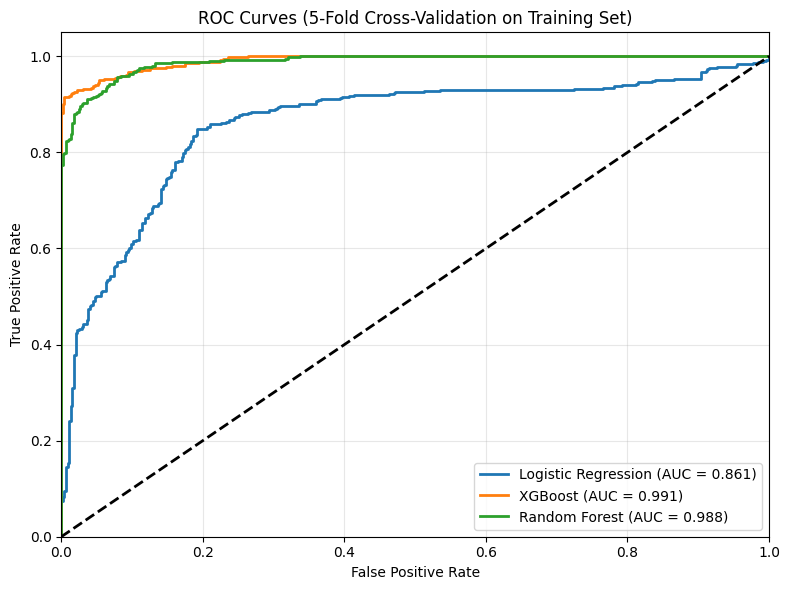

In [ ]:
# =============================================================================
# 6. 交叉验证 ROC 曲线对比（基于训练集CV预测概率）
# =============================================================================
plt.figure(figsize=(8, 6))
for name in models.keys():
    y_proba = cross_val_predict(models[name], X_train, y_train, cv=kfold, method='predict_proba')[:, 1]
    fpr, tpr, _ = roc_curve(y_train, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (5-Fold Cross-Validation on Training Set)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

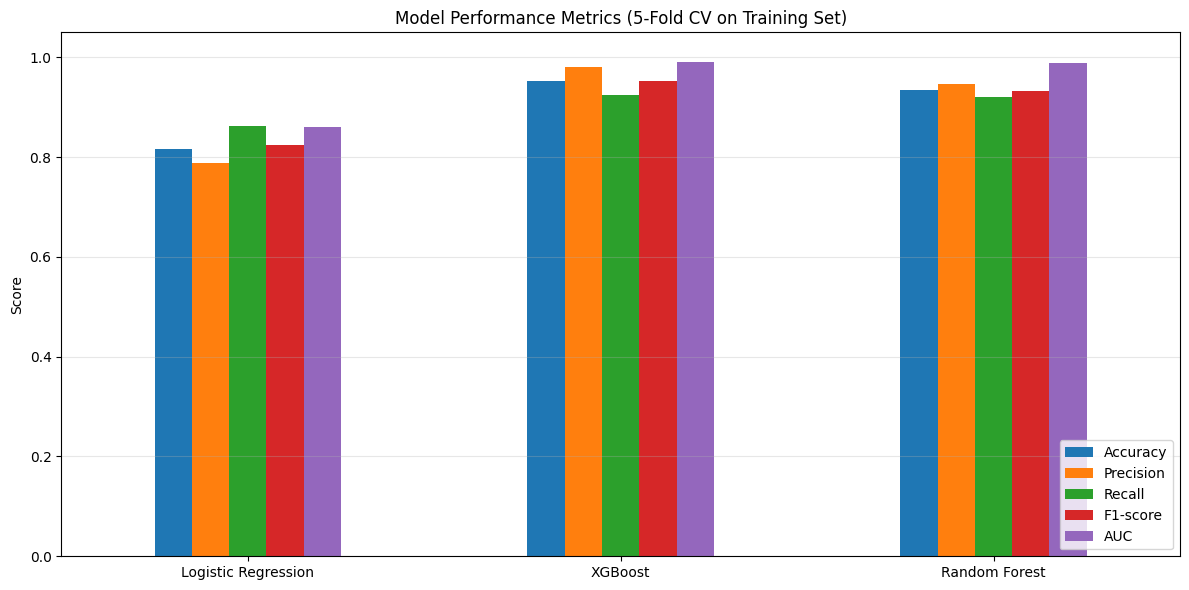


模型性能对比表（K=5交叉验证）
                     Accuracy Precision    Recall  F1-score       AUC
Logistic Regression  0.815436  0.788934  0.861298  0.823529  0.860692
XGBoost               0.95302  0.980998  0.923937  0.951613  0.991417
Random Forest        0.934004  0.947005  0.919463  0.933031  0.988289


In [ ]:
# =============================================================================
# 7. 交叉验证指标汇总条形图
# =============================================================================
metrics_df = pd.DataFrame(cv_results).T[['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC']]
metrics_df.plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance Metrics (5-Fold CV on Training Set)')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 打印详细对比表
print("\n" + "="*60)
print("模型性能对比表（K=5交叉验证）")
print("="*60)
print(metrics_df.to_string())


In [ ]:
# =============================================================================
# 8. 使用全部训练数据训练最终模型，并在独立测试集上评估
# =============================================================================
print("\n" + "="*60)
print("在全部训练数据上重新训练模型，并在独立测试集上评估...")
print("="*60)

final_models = {}
test_results = {}
test_probs = {}  # 保存测试集预测概率用于诊断图

for name, model in models.items():
    # 在完整训练集上训练
    model.fit(X_train, y_train)
    final_models[name] = model

    # 在测试集上评估
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    test_probs[name] = y_prob

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_prob)

    test_results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'AUC': auc_score
    }

    print(f"\n{name} 在独立测试集上的表现:")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-score : {f1:.4f}")
    print(f"  AUC      : {auc_score:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Non-landslide', 'Landslide']))


在全部训练数据上重新训练模型，并在独立测试集上评估...

Logistic Regression 在独立测试集上的表现:
  Accuracy : 0.8259
  Precision: 0.7829
  Recall   : 0.9018
  F1-score : 0.8382
  AUC      : 0.8987
               precision    recall  f1-score   support

Non-landslide       0.88      0.75      0.81       112
    Landslide       0.78      0.90      0.84       112

     accuracy                           0.83       224
    macro avg       0.83      0.83      0.82       224
 weighted avg       0.83      0.83      0.82       224


XGBoost 在独立测试集上的表现:
  Accuracy : 0.9777
  Precision: 0.9908
  Recall   : 0.9643
  F1-score : 0.9774
  AUC      : 0.9994
               precision    recall  f1-score   support

Non-landslide       0.97      0.99      0.98       112
    Landslide       0.99      0.96      0.98       112

     accuracy                           0.98       224
    macro avg       0.98      0.98      0.98       224
 weighted avg       0.98      0.98      0.98       224


Random Forest 在独立测试集上的表现:
  Accuracy : 0.9688
  P